# World Cup Rosters - Exploratory Data Analysis

This notebook explores the FIFA World Cup roster data from 1998-2026, analyzing player demographics, club affiliations, and career patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/processed/rosters_combined.csv')
df['DOB'] = pd.to_datetime(df['DOB'])

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (6463, 12)

Columns: ['Country', 'Number', 'Position', 'Player', 'DOB', 'Age', 'Caps', 'Club', 'Club_Country', 'Home_Country_Flag', 'Year', 'Previous_World_Cups']


,Country,Number,Position,Player,DOB,Age,Caps,Club,Club_Country,Home_Country_Flag,Year,Previous_World_Cups
0,Argentina,18.0,FW,Abel Balbo,1966-06-01,32,34,NaN,Italy,False,1998,0
1,Argentina,10.0,MF,Ariel Ortega,1974-03-04,24,50,NaN,Spain,False,1998,0
2,Argentina,1.0,GK,Carlos Roa,1969-08-15,28,10,NaN,Spain,False,1998,0
3,Argentina,7.0,FW,Claudio López,1974-07-17,23,25,NaN,Spain,False,1998,0
4,Argentina,8.0,MF,Diego Simeone,1970-04-28,28,69,NaN,Italy,False,1998,0


## 1. Dataset Overview

In [2]:
# Basic statistics
print("=== Dataset Statistics ===")
print(f"Total records: {len(df):,}")
print(f"Unique players: {df['Player'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Years: {sorted(df['Year'].unique())}")
print(f"\nRecords per year:")
print(df['Year'].value_counts().sort_index())

=== Dataset Statistics ===
Total records: 6,463
Unique players: 4,885
Countries: 76
Years: [np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022), np.int64(2026)]

Records per year:
Year
1998     705
2002     736
2006     736
2010     736
2014     736
2018     736
2022     831
2026    1247
Name: count, dtype: int64


In [3]:
# Missing data analysis
print("=== Missing Data ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

=== Missing Data ===
              Missing Count  Percentage
Club                   6460       99.95
Number                  961       14.87
Club_Country              3        0.05


## 2. Age Analysis

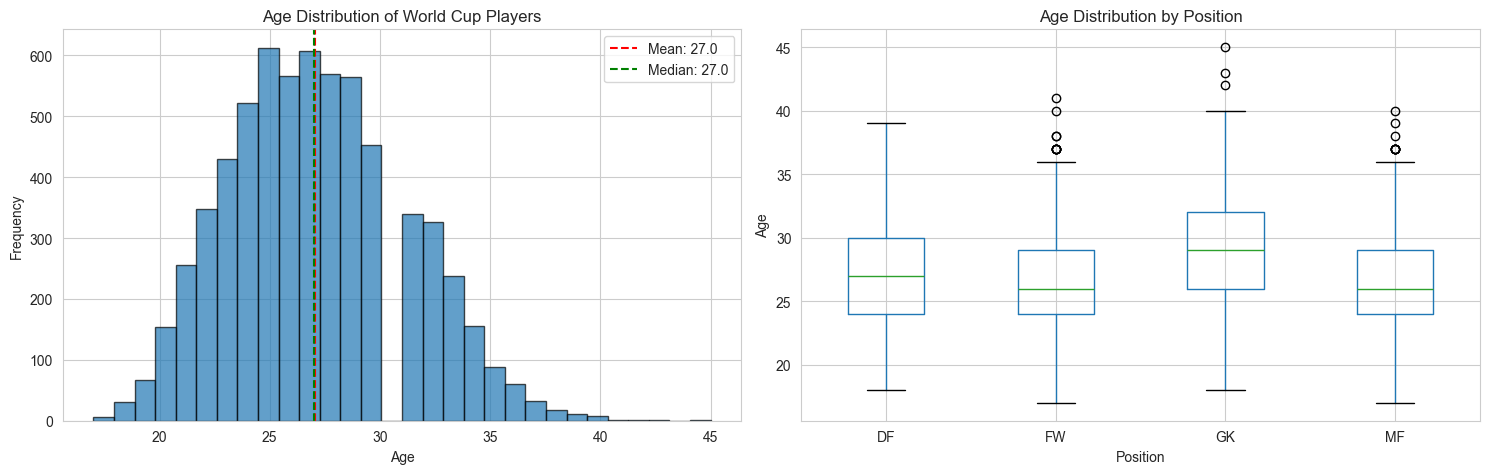


Age statistics by position:
           count   mean   std   min   25%   50%   75%   max
Position                                                   
DF        2142.0  27.17  3.79  18.0  24.0  27.0  30.0  39.0
FW        1411.0  26.54  3.98  17.0  24.0  26.0  29.0  41.0
GK         821.0  28.95  4.51  18.0  26.0  29.0  32.0  45.0
MF        2089.0  26.53  3.80  17.0  24.0  26.0  29.0  40.0


In [4]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall age distribution
axes[0].hist(df['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution of World Cup Players')
axes[0].legend()

# Age by position
df.boxplot(column='Age', by='Position', ax=axes[1])
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Age')
axes[1].set_title('Age Distribution by Position')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nAge statistics by position:")
print(df.groupby('Position')['Age'].describe().round(2))

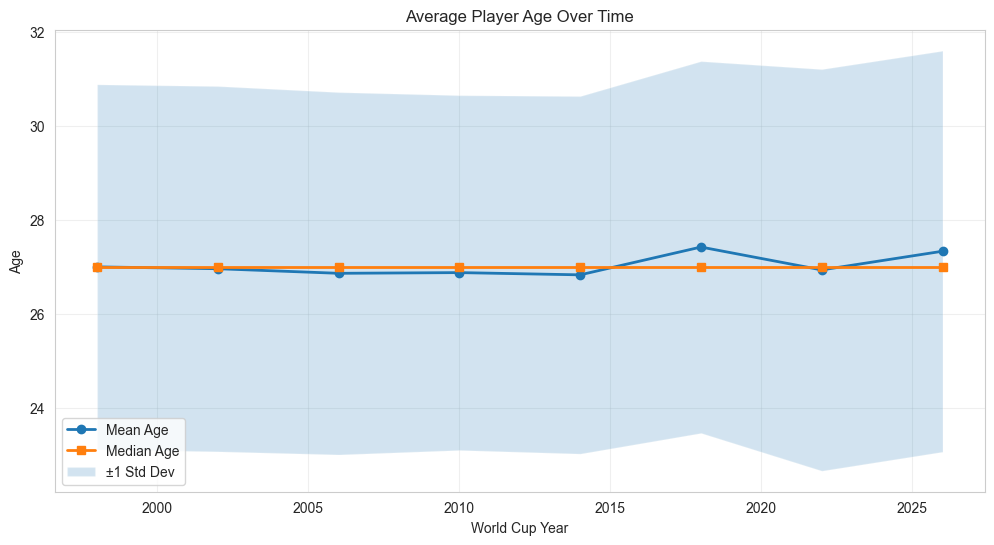

In [5]:
# Age trends over time
age_by_year = df.groupby('Year')['Age'].agg(['mean', 'median', 'std']).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(age_by_year['Year'], age_by_year['mean'], marker='o', label='Mean Age', linewidth=2)
plt.plot(age_by_year['Year'], age_by_year['median'], marker='s', label='Median Age', linewidth=2)
plt.fill_between(age_by_year['Year'], 
                 age_by_year['mean'] - age_by_year['std'],
                 age_by_year['mean'] + age_by_year['std'],
                 alpha=0.2, label='±1 Std Dev')
plt.xlabel('World Cup Year')
plt.ylabel('Age')
plt.title('Average Player Age Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Position Analysis

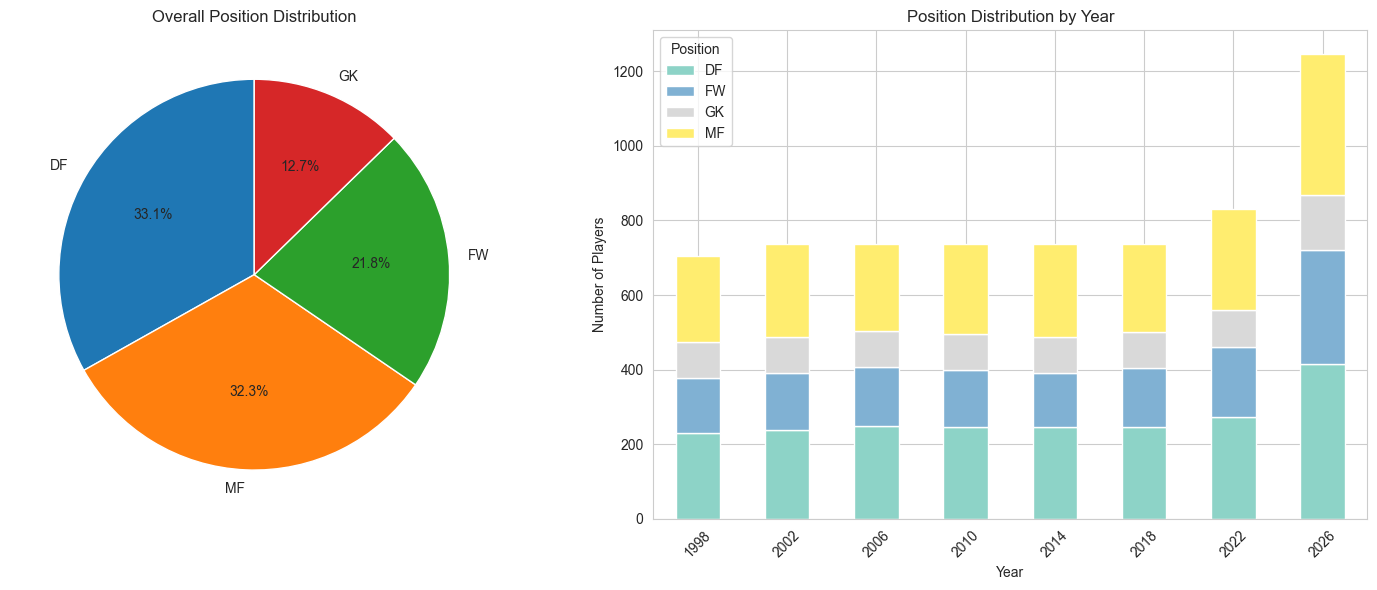


Position counts:
Position
DF    2142
MF    2089
FW    1411
GK     821
Name: count, dtype: int64


In [6]:
# Position distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall distribution
position_counts = df['Position'].value_counts()
axes[0].pie(position_counts.values, labels=position_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Overall Position Distribution')

# Position distribution by year
position_by_year = df.groupby(['Year', 'Position']).size().unstack(fill_value=0)
position_by_year.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Players')
axes[1].set_title('Position Distribution by Year')
axes[1].legend(title='Position')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nPosition counts:")
print(position_counts)

## 4. Club Country Analysis

<Figure size 1200x600 with 0 Axes>

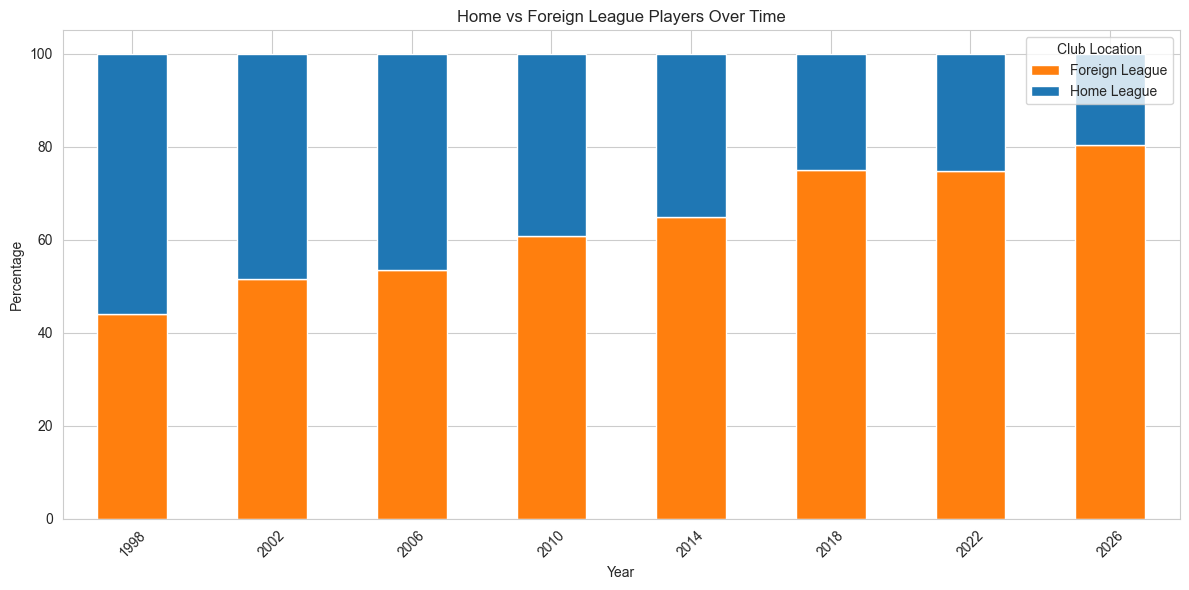


Home vs Foreign percentages by year:
Home_Country_Flag  False  True 
Year                           
1998               44.11  55.89
2002               51.63  48.37
2006               53.40  46.60
2010               60.73  39.27
2014               64.81  35.19
2018               75.00  25.00
2022               74.85  25.15
2026               80.27  19.73


In [7]:
# Home vs Foreign players
home_foreign = df.groupby('Year')['Home_Country_Flag'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(12, 6))
home_foreign.plot(kind='bar', stacked=True, color=['#ff7f0e', '#1f77b4'])
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title('Home vs Foreign League Players Over Time')
plt.legend(['Foreign League', 'Home League'], title='Club Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nHome vs Foreign percentages by year:")
print(home_foreign.round(2))

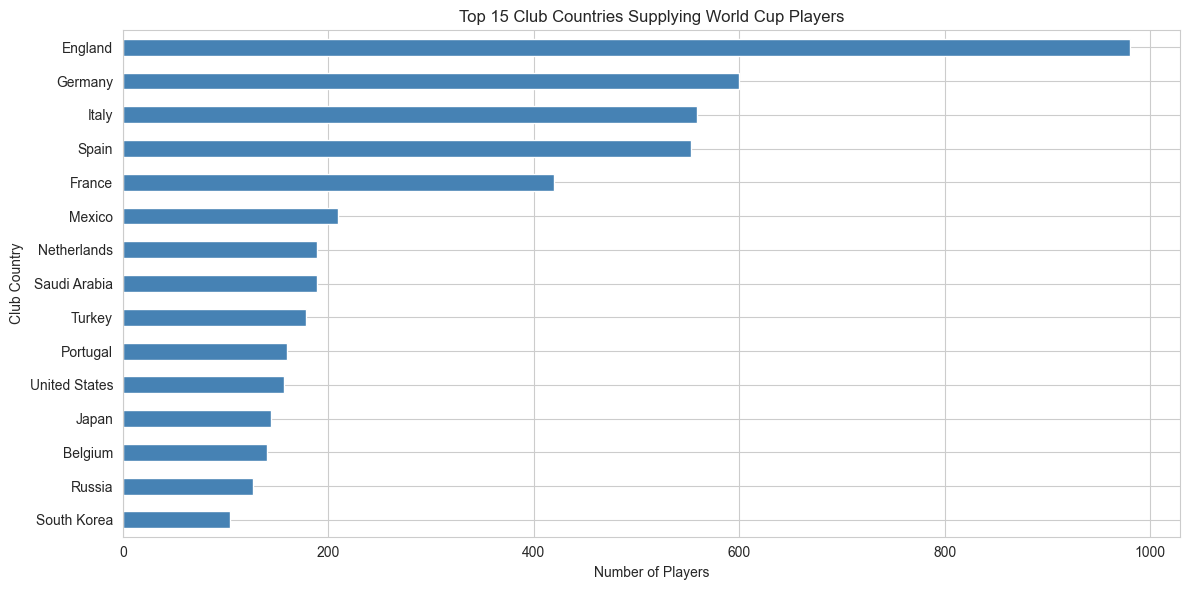


Top 15 club countries:
Club_Country
England          980
Germany          600
Italy            559
Spain            553
France           420
Mexico           209
Netherlands      189
Saudi Arabia     189
Turkey           178
Portugal         160
United States    157
Japan            144
Belgium          140
Russia           127
South Korea      104
Name: count, dtype: int64


In [8]:
# Top club countries
top_club_countries = df['Club_Country'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_club_countries.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Players')
plt.ylabel('Club Country')
plt.title('Top 15 Club Countries Supplying World Cup Players')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 15 club countries:")
print(top_club_countries)

## 5. World Cup Veterans Analysis

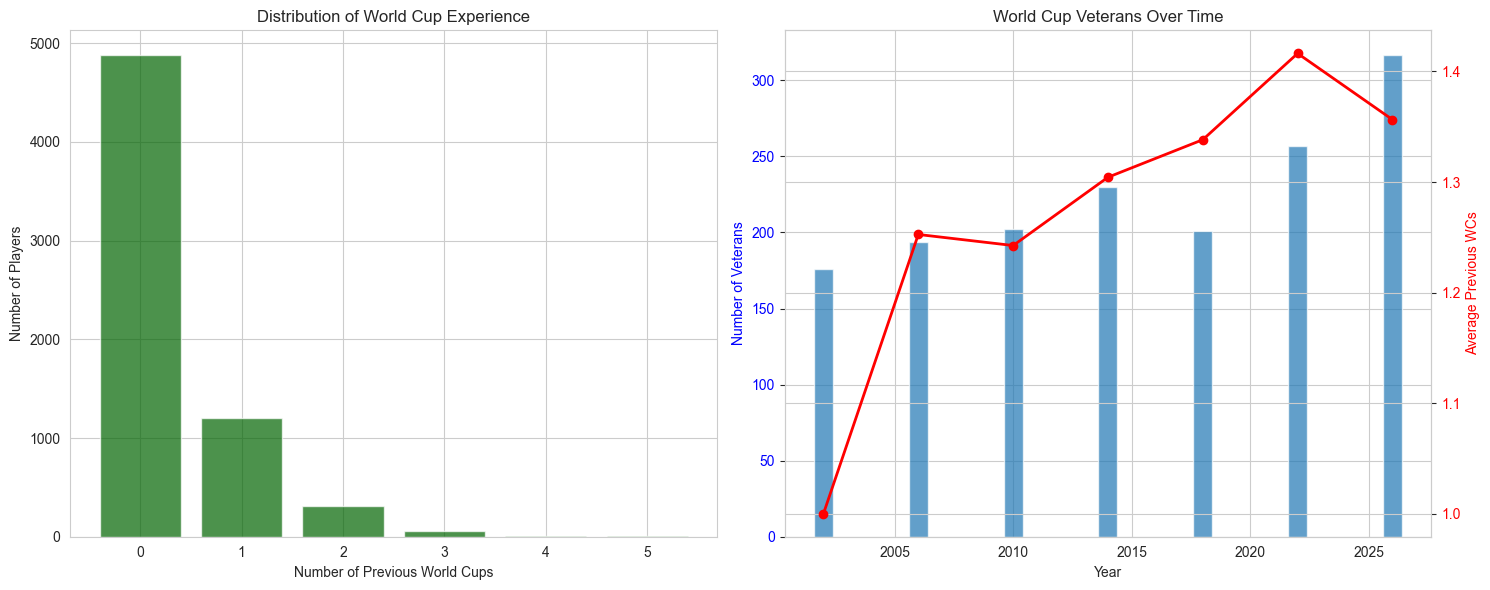


Previous World Cups statistics:
count    6463.000000
mean        0.314560
std         0.622678
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: Previous_World_Cups, dtype: float64


In [9]:
# Previous World Cups distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution
prev_wc_counts = df['Previous_World_Cups'].value_counts().sort_index()
axes[0].bar(prev_wc_counts.index, prev_wc_counts.values, color='darkgreen', alpha=0.7)
axes[0].set_xlabel('Number of Previous World Cups')
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Distribution of World Cup Experience')
axes[0].set_xticks(range(int(df['Previous_World_Cups'].max()) + 1))

# Veterans over time
veterans_by_year = df[df['Previous_World_Cups'] >= 1].groupby('Year')['Previous_World_Cups'].agg(['count', 'mean'])
ax2 = axes[1]
ax2.bar(veterans_by_year.index, veterans_by_year['count'], alpha=0.7, label='Veteran Count')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Veterans', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2_twin = ax2.twinx()
ax2_twin.plot(veterans_by_year.index, veterans_by_year['mean'], color='red', marker='o', linewidth=2, label='Avg Experience')
ax2_twin.set_ylabel('Average Previous WCs', color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')

axes[1].set_title('World Cup Veterans Over Time')
plt.tight_layout()
plt.show()

print("\nPrevious World Cups statistics:")
print(df['Previous_World_Cups'].describe())

In [10]:
# Find the most experienced players
veterans = df[df['Previous_World_Cups'] >= 3].copy()
veterans_summary = veterans.groupby('Player').agg({
    'Previous_World_Cups': 'max',
    'Country': 'first',
    'Year': lambda x: ', '.join(map(str, sorted(x.unique()))),
    'Position': 'first'
}).sort_values('Previous_World_Cups', ascending=False)

print("\n=== World Cup Legends (3+ tournaments) ===")
print(veterans_summary.head(20).to_string())


=== World Cup Legends (3+ tournaments) ===
                      Previous_World_Cups      Country              Year Position
Player                                                                           
Guillermo Ochoa                         5       Mexico  2018, 2022, 2026       GK
Cristiano Ronaldo                       5     Portugal  2018, 2022, 2026       FW
Lionel Messi                            5    Argentina  2018, 2022, 2026       FW
Luis Suárez                             4      Uruguay        2022, 2026       FW
Manuel Neuer                            4      Germany        2022, 2026       GK
Luka Modrić                             4      Croatia        2022, 2026       MF
Andrés Guardado                         4       Mexico        2018, 2022       MF
Rafael Márquez                          4       Mexico        2014, 2018       DF
Gianluigi Buffon                        4        Italy        2010, 2014       GK
Thierry Henry                           3       France

## 6. Country Analysis

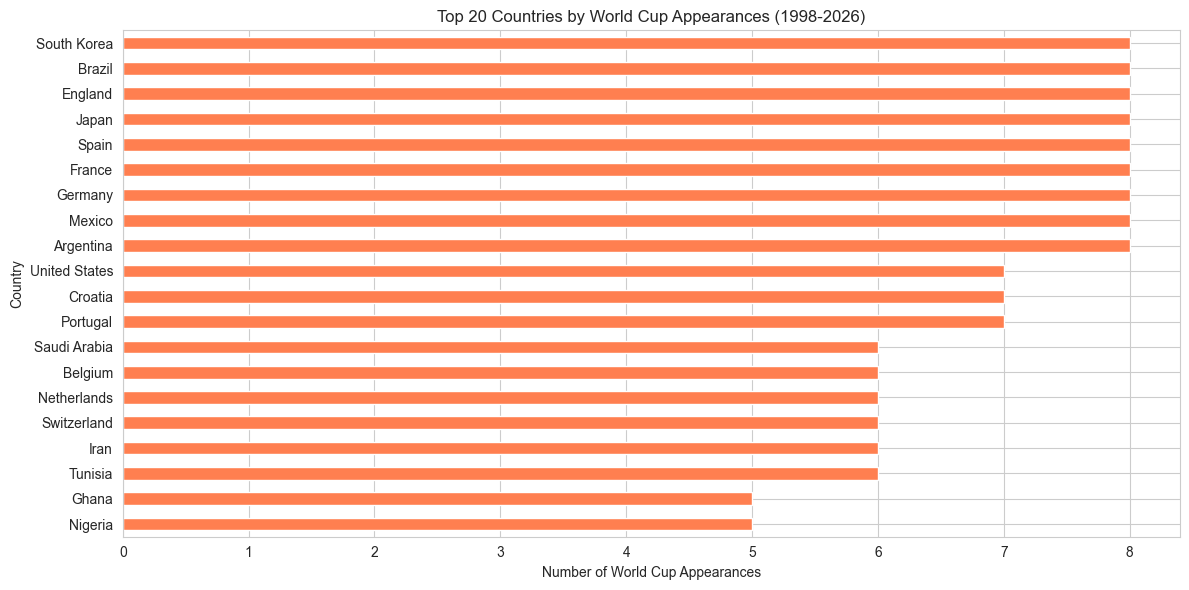


Top 20 countries by appearances:
Country
South Korea      8
Brazil           8
England          8
Japan            8
Spain            8
France           8
Germany          8
Mexico           8
Argentina        8
United States    7
Croatia          7
Portugal         7
Saudi Arabia     6
Belgium          6
Netherlands      6
Switzerland      6
Iran             6
Tunisia          6
Ghana            5
Nigeria          5
Name: Year, dtype: int64


In [11]:
# Countries with most appearances
country_appearances = df.groupby('Country')['Year'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
country_appearances.plot(kind='barh', color='coral')
plt.xlabel('Number of World Cup Appearances')
plt.ylabel('Country')
plt.title('Top 20 Countries by World Cup Appearances (1998-2026)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 countries by appearances:")
print(country_appearances)

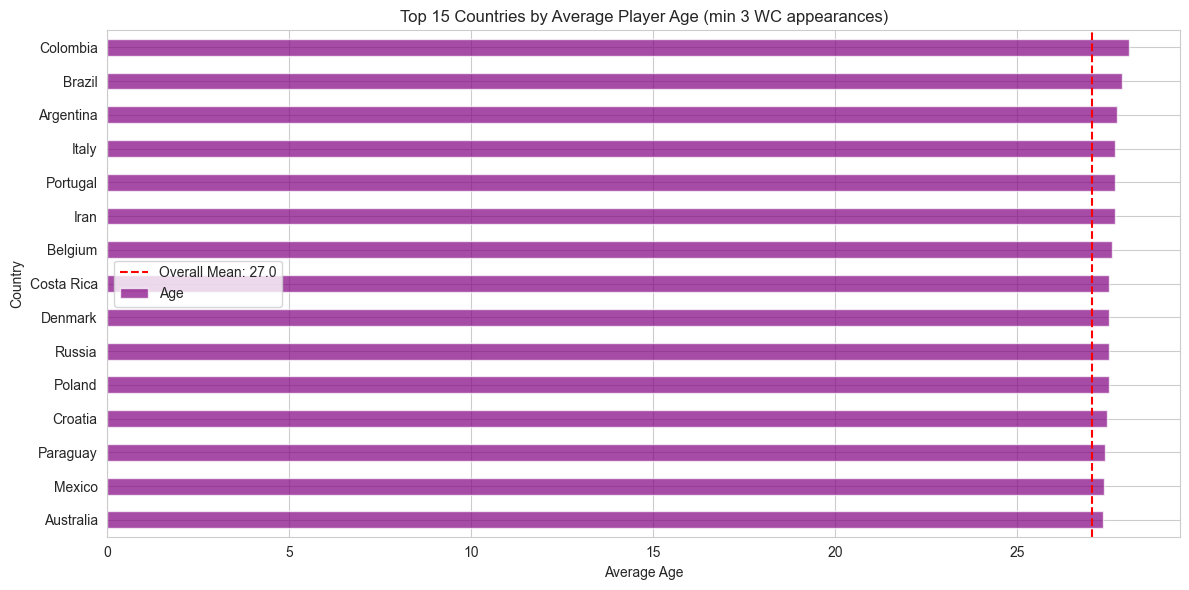

In [12]:
# Average age by country (for countries with 3+ appearances)
frequent_countries = df.groupby('Country')['Year'].nunique()
frequent_countries = frequent_countries[frequent_countries >= 3].index

avg_age_by_country = df[df['Country'].isin(frequent_countries)].groupby('Country')['Age'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
avg_age_by_country.plot(kind='barh', color='purple', alpha=0.7)
plt.xlabel('Average Age')
plt.ylabel('Country')
plt.title('Top 15 Countries by Average Player Age (min 3 WC appearances)')
plt.gca().invert_yaxis()
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Overall Mean: {df["Age"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Squad Size Evolution

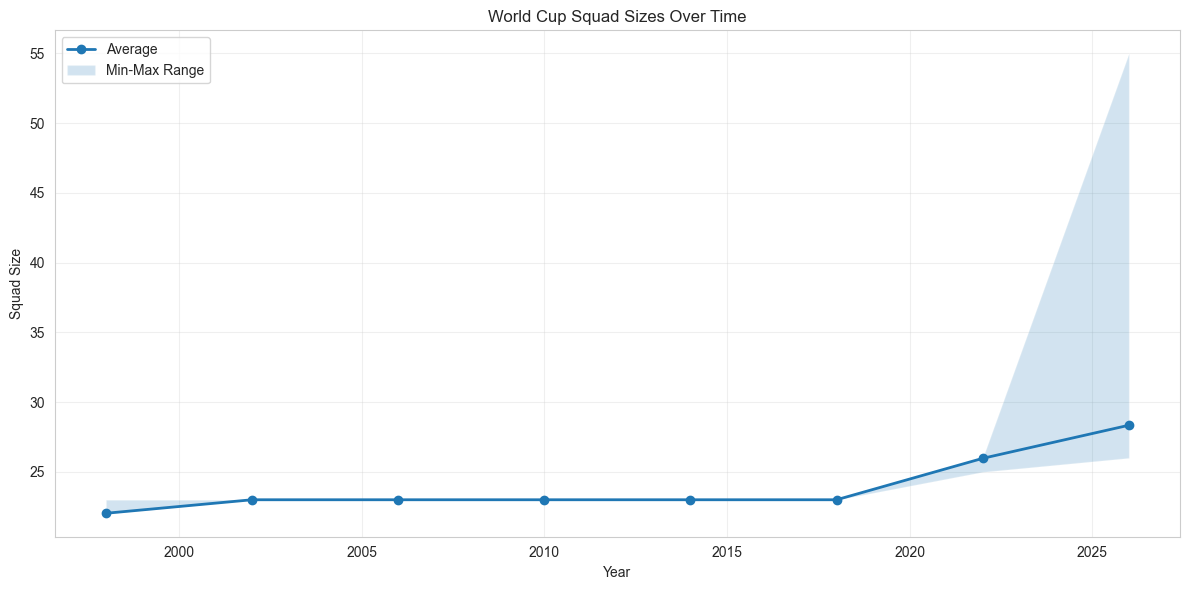


Squad size statistics by year:
       mean  min  max   std
Year                       
1998  22.03   22   23  0.18
2002  23.00   23   23  0.00
2006  23.00   23   23  0.00
2010  23.00   23   23  0.00
2014  23.00   23   23  0.00
2018  23.00   23   23  0.00
2022  25.97   25   26  0.18
2026  28.34   26   55  5.89


In [13]:
# Squad sizes over time
squad_sizes = df.groupby(['Year', 'Country']).size().reset_index(name='Squad_Size')
squad_stats = squad_sizes.groupby('Year')['Squad_Size'].agg(['mean', 'min', 'max', 'std'])

plt.figure(figsize=(12, 6))
plt.plot(squad_stats.index, squad_stats['mean'], marker='o', linewidth=2, label='Average')
plt.fill_between(squad_stats.index, squad_stats['min'], squad_stats['max'], alpha=0.2, label='Min-Max Range')
plt.xlabel('Year')
plt.ylabel('Squad Size')
plt.title('World Cup Squad Sizes Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSquad size statistics by year:")
print(squad_stats.round(2))

## 8. Key Insights Summary

In [14]:
print("=== KEY INSIGHTS ===")
print(f"\n1. AGE TRENDS")
print(f"   - Average player age: {df['Age'].mean():.1f} years")
print(f"   - Youngest player: {df['Age'].min()} years")
print(f"   - Oldest player: {df['Age'].max()} years")
print(f"   - Goalkeepers are oldest (avg: {df[df['Position']=='GK']['Age'].mean():.1f})")
print(f"   - Forwards are youngest (avg: {df[df['Position']=='FW']['Age'].mean():.1f})")

print(f"\n2. EXPERIENCE")
print(f"   - Players with 3+ World Cups: {len(df[df['Previous_World_Cups'] >= 3])}")
print(f"   - Maximum previous WCs: {df['Previous_World_Cups'].max()}")
print(f"   - Average experience: {df['Previous_World_Cups'].mean():.2f} previous WCs")

print(f"\n3. CLUB DIVERSITY")
print(f"   - Players in home leagues: {df['Home_Country_Flag'].sum()} ({df['Home_Country_Flag'].mean()*100:.1f}%)")
print(f"   - Players in foreign leagues: {(~df['Home_Country_Flag']).sum()} ({(~df['Home_Country_Flag']).mean()*100:.1f}%)")
print(f"   - Top club country: {df['Club_Country'].value_counts().index[0]} ({df['Club_Country'].value_counts().iloc[0]} players)")

print(f"\n4. SQUAD COMPOSITION")
print(f"   - Average squad size: {df.groupby(['Year', 'Country']).size().mean():.1f} players")
print(f"   - Position breakdown: DF ({(df['Position']=='DF').sum()}), MF ({(df['Position']=='MF').sum()}), FW ({(df['Position']=='FW').sum()}), GK ({(df['Position']=='GK').sum()})")

print(f"\n5. PARTICIPATION")
print(f"   - Total countries: {df['Country'].nunique()}")
print(f"   - Countries in all 8 tournaments: {(df.groupby('Country')['Year'].nunique() == 8).sum()}")
print(f"   - Most frequent participant: {country_appearances.index[0]} ({country_appearances.iloc[0]} tournaments)")

=== KEY INSIGHTS ===

1. AGE TRENDS
   - Average player age: 27.0 years
   - Youngest player: 17 years
   - Oldest player: 45 years
   - Goalkeepers are oldest (avg: 28.9)
   - Forwards are youngest (avg: 26.5)

2. EXPERIENCE
   - Players with 3+ World Cups: 67
   - Maximum previous WCs: 5
   - Average experience: 0.31 previous WCs

3. CLUB DIVERSITY
   - Players in home leagues: 2280 (35.3%)
   - Players in foreign leagues: 4183 (64.7%)
   - Top club country: England (980 players)

4. SQUAD COMPOSITION
   - Average squad size: 24.1 players
   - Position breakdown: DF (2142), MF (2089), FW (1411), GK (821)

5. PARTICIPATION
   - Total countries: 76
   - Countries in all 8 tournaments: 9
   - Most frequent participant: South Korea (8 tournaments)


## 9. Visualization Recommendations

Based on this analysis, here are the most impactful visualizations for the D3.js dashboard:

### Priority 1 (Must Have):
1. **Age Distribution Heatmap** - Shows age trends across years and positions
2. **Club Country Diversity Map** - Geographic visualization of player origins
3. **Home vs Foreign Players Timeline** - Trend of internationalization
4. **World Cup Veterans Highlight** - Interactive view of experienced players

### Priority 2 (Nice to Have):
5. **Position Distribution Sunburst** - Squad composition by country
6. **Country Participation Timeline** - Which countries appeared when
7. **Age vs Experience Scatter** - Relationship between age and WC experience
8. **Squad Size Evolution** - How squad sizes changed over time

### Data Quality Notes:
- Club_Country has some missing values - may need manual cleanup
- DOB missing for some older players
- 2026 data is preliminary and will need updates